# Prepocessing the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cols="""duration,
protocol_type,
service,
flag,
src_bytes,
dst_bytes,
land,
wrong_fragment,
urgent,
hot,
num_failed_logins,
logged_in,
num_compromised,
root_shell,
su_attempted,
num_root,
num_file_creations,
num_shells,
num_access_files,
num_outbound_cmds,
is_host_login,
is_guest_login,
count,
srv_count,
serror_rate,
srv_serror_rate,
rerror_rate,
srv_rerror_rate,
same_srv_rate,
diff_srv_rate,
srv_diff_host_rate,
dst_host_count,
dst_host_srv_count,
dst_host_same_srv_rate,
dst_host_diff_srv_rate,
dst_host_same_src_port_rate,
dst_host_srv_diff_host_rate,
dst_host_serror_rate,
dst_host_srv_serror_rate,
dst_host_rerror_rate,
dst_host_srv_rerror_rate"""

columns=[]
for c in cols.split(','):
    if(c.strip()):
       columns.append(c.strip())

columns.append('target')
#print(columns)
print(len(columns))

42


In [3]:
attacks_types = {
    'normal': 'normal',
'back': 'dos',
'buffer_overflow': 'u2r',
'ftp_write': 'r2l',
'guess_passwd': 'r2l',
'imap': 'r2l',
'ipsweep': 'probe',
'land': 'dos',
'loadmodule': 'u2r',
'multihop': 'r2l',
'neptune': 'dos',
'nmap': 'probe',
'perl': 'u2r',
'phf': 'r2l',
'pod': 'dos',
'portsweep': 'probe',
'rootkit': 'u2r',
'satan': 'probe',
'smurf': 'dos',
'spy': 'r2l',
'teardrop': 'dos',
'warezclient': 'r2l',
'warezmaster': 'r2l',
}

In [4]:
path = "../input/kdd-cup-1999-data/kddcup.data_10_percent.gz"
df = pd.read_csv(path,names=columns)

#Adding Attack Type column
df['Attack Type'] = df.target.apply(lambda r:attacks_types[r[:-1]])

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal


In [5]:
df['Attack Type'].value_counts()

dos       391458
normal     97278
probe       4107
r2l         1126
u2r           52
Name: Attack Type, dtype: int64

# Visualizing the data

In [6]:
#Visualization
def bar_graph(feature):
    df[feature].value_counts().plot(kind="bar")

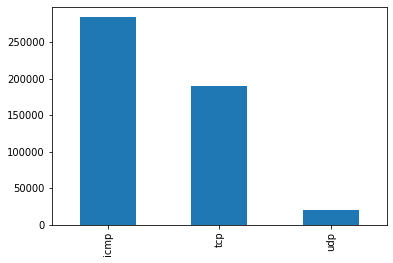

In [7]:
bar_graph('protocol_type')

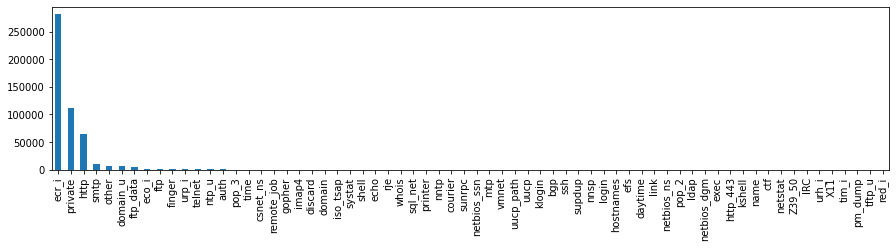

In [8]:
plt.figure(figsize=(15,3))
bar_graph('service')

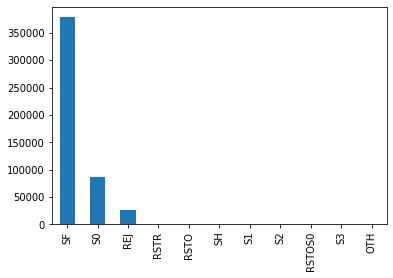

In [9]:
bar_graph('flag')

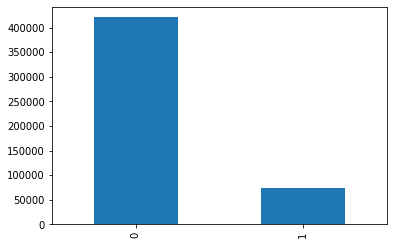

In [10]:
bar_graph('logged_in')

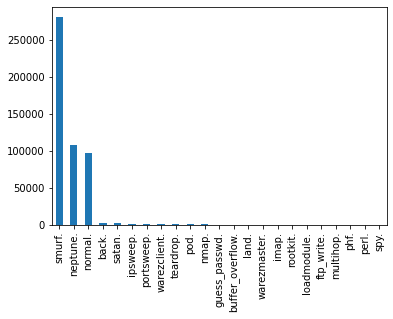

In [11]:
bar_graph('target')

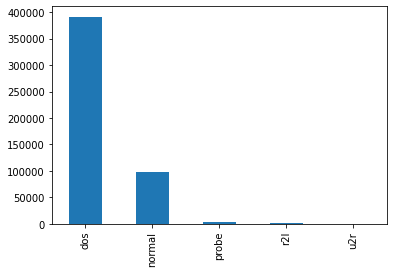

In [12]:
bar_graph('Attack Type')

In [13]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'target', 'Attack Type'],
      dtype='object')

# Removing highly correlated columns

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.dropna will be keyword-only
  """Entry point for launching an IPython kernel.


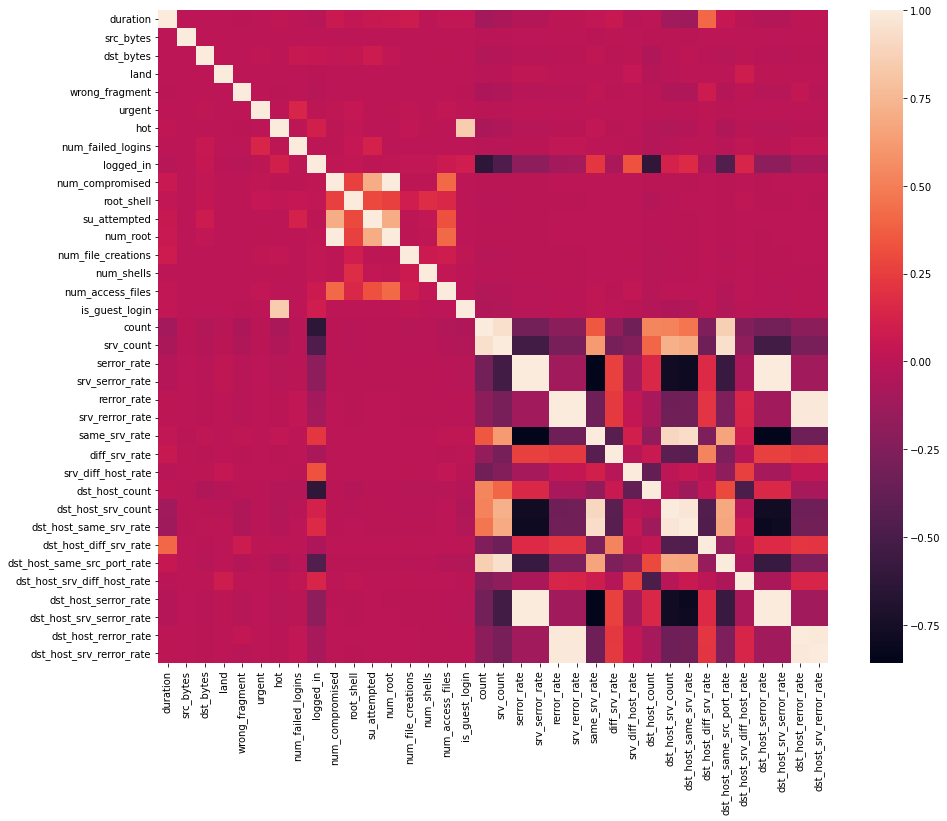

In [14]:
df = df.dropna('columns')# drop columns with NaN

df = df[[col for col in df if df[col].nunique() > 1]]# keep columns where there are more than 1 unique values

corr = df.corr()

plt.figure(figsize=(15,12))

sns.heatmap(corr)

plt.show()

In [15]:
#This variable is highly correlated with num_compromised and should be ignored for analysis.
#(Correlation = 0.9938277978738366)
df.drop('num_root',axis = 1,inplace = True)

#This variable is highly correlated with serror_rate and should be ignored for analysis.
#(Correlation = 0.9983615072725952)
df.drop('srv_serror_rate',axis = 1,inplace = True)

#This variable is highly correlated with rerror_rate and should be ignored for analysis.
#(Correlation = 0.9947309539817937)
df.drop('srv_rerror_rate',axis = 1, inplace=True)

#This variable is highly correlated with srv_serror_rate and should be ignored for analysis.
#(Correlation = 0.9993041091850098)
df.drop('dst_host_srv_serror_rate',axis = 1, inplace=True)

#This variable is highly correlated with rerror_rate and should be ignored for analysis.
#(Correlation = 0.9869947924956001)
df.drop('dst_host_serror_rate',axis = 1, inplace=True)

#This variable is highly correlated with srv_rerror_rate and should be ignored for analysis.
#(Correlation = 0.9821663427308375)
df.drop('dst_host_rerror_rate',axis = 1, inplace=True)

#This variable is highly correlated with rerror_rate and should be ignored for analysis.
#(Correlation = 0.9851995540751249)
df.drop('dst_host_srv_rerror_rate',axis = 1, inplace=True)

#This variable is highly correlated with dst_host_srv_count and should be ignored for analysis.
#(Correlation = 0.9736854572953938)
df.drop('dst_host_same_srv_rate',axis = 1, inplace=True)

In [16]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.0,9,9,0.0,0.11,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.0,19,19,0.0,0.05,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.0,29,29,0.0,0.03,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.0,39,39,0.0,0.03,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.0,49,49,0.0,0.02,0.0,normal.,normal


# Label encoding the features

In [17]:
#protocol_type feature mapping
pmap = {'icmp':0,'tcp':1,'udp':2}
df['protocol_type'] = df['protocol_type'].map(pmap)

In [18]:
#flag feature mapping
fmap = {'SF':0,'S0':1,'REJ':2,'RSTR':3,'RSTO':4,'SH':5 ,'S1':6 ,'S2':7,'RSTOS0':8,'S3':9 ,'OTH':10}
df['flag'] = df['flag'].map(fmap)

In [19]:
#attack type feature mapping
amap = {'dos':0,'normal':1,'probe':2,'r2l':3,'u2r':4}
df['Attack Type'] = df['Attack Type'].map(amap)

In [20]:
 df.drop('service',axis = 1,inplace= True)

# Building and training a Neural Network

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

In [22]:
import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, Input, Concatenate, Add

In [23]:
df = df.drop(['target',], axis=1)
print(df.shape)

# Target variable and train set
Y = df[['Attack Type']]
X = df.drop(['Attack Type',], axis=1)

sc = MinMaxScaler()
X = sc.fit_transform(X)

(494021, 31)


In [24]:
df.columns

Index(['duration', 'protocol_type', 'flag', 'src_bytes', 'dst_bytes', 'land',
       'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
       'num_compromised', 'root_shell', 'su_attempted', 'num_file_creations',
       'num_shells', 'num_access_files', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'Attack Type'],
      dtype='object')

In [28]:
from imblearn.over_sampling import RandomOverSampler

# Step 1: Apply Random Oversampling to balance the classes
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)

# Step 2: Trim resampled dataset to 65406 samples (45695 train + 19711 test)
total_samples = 45695 + 19711
assert len(X_resampled) >= total_samples, "Not enough samples after resampling."

X_resampled = X_resampled[:total_samples]
y_resampled = y_resampled[:total_samples]

# Step 3: Perform final train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_resampled,
    y_resampled,
    train_size=45695,
    test_size=19711,
    random_state=42,
    shuffle=True
)

In [29]:
df.to_csv("ids.csv", index=False)

In [30]:
pd.read_csv("ids.csv")

,duration,protocol_type,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,...,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,Attack Type
0,0,1,0,181,5450,0,0,0,0,0,...,0.0,1.0,0.0,0.00,9,9,0.0,0.11,0.00,1
1,0,1,0,239,486,0,0,0,0,0,...,0.0,1.0,0.0,0.00,19,19,0.0,0.05,0.00,1
2,0,1,0,235,1337,0,0,0,0,0,...,0.0,1.0,0.0,0.00,29,29,0.0,0.03,0.00,1
3,0,1,0,219,1337,0,0,0,0,0,...,0.0,1.0,0.0,0.00,39,39,0.0,0.03,0.00,1
4,0,1,0,217,2032,0,0,0,0,0,...,0.0,1.0,0.0,0.00,49,49,0.0,0.02,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,1,0,310,1881,0,0,0,0,0,...,0.0,1.0,0.0,0.40,86,255,0.0,0.01,0.05,1
494017,0,1,0,282,2286,0,0,0,0,0,...,0.0,1.0,0.0,0.00,6,255,0.0,0.17,0.05,1
494018,0,1,0,203,1200,0,0,0,0,0,...,0.0,1.0,0.0,0.17,16,255,0.0,0.06,0.05,1
494019,0,1,0,291,1200,0,0,0,0,0,...,0.0,1.0,0.0,0.17,26,255,0.0,0.04,0.05,1


# Shallow Neural Network

In [31]:
shallow_model = Sequential([
    Dense(1024, input_dim=30, activation='tanh'),
    Dropout(0.01),
    Dense(5, activation='softmax')
])

In [32]:
shallow_model = Sequential([
    Dense(8, input_dim=30, activation='sigmoid'),  # smaller layer, suboptimal activation
    Dropout(0.8),                                  # high dropout
    Dense(5, activation='linear')                  # poor output activation for classification
])

In [33]:
shallow_model.compile(loss ='sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

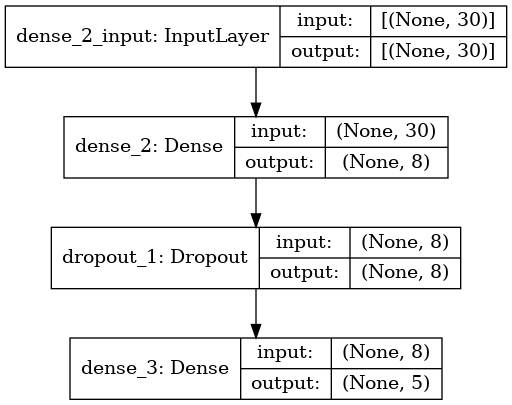

In [34]:
tf.keras.utils.plot_model(shallow_model, to_file="shallow_model.png", show_shapes=True)

In [35]:
shallow_model.fit(X_train, Y_train.values.ravel(), epochs=10, batch_size=32)

Epoch 1/10
1428/1428 [==============================] - 4s 2ms/step - loss: 3.6576 - accuracy: 0.5087
Epoch 2/10
1428/1428 [==============================] - 3s 2ms/step - loss: 2.8044 - accuracy: 0.5223
Epoch 3/10
1428/1428 [==============================] - 3s 2ms/step - loss: 2.1820 - accuracy: 0.5147
Epoch 4/10
1428/1428 [==============================] - 3s 2ms/step - loss: 1.7324 - accuracy: 0.4984
Epoch 5/10
1428/1428 [==============================] - 3s 2ms/step - loss: 1.4664 - accuracy: 0.4513
Epoch 6/10
1428/1428 [==============================] - 3s 2ms/step - loss: 1.4511 - accuracy: 0.4340
Epoch 7/10
1428/1428 [==============================] - 3s 2ms/step - loss: 1.4229 - accuracy: 0.3405
Epoch 8/10
1428/1428 [==============================] - 3s 2ms/step - loss: 1.4185 - accuracy: 0.3376
Epoch 9/10
1428/1428 [==============================] - 3s 2ms/step - loss: 1.4593 - accuracy: 0.3107
Epoch 10/10
1428/1428 [==============================] - 2s 2ms/step - loss: 1.455

## Deep Neural Network Paper Model

In [36]:
# DNN model structure based on research paper
deep_model = Sequential([
    Dense(128, input_dim=30, activation='tanh'),  # Input layer + 1st hidden layer
    Dropout(0.01),
    Dense(64, activation='tanh'),                 # 2nd hidden layer
    Dropout(0.01),
    Dense(32, activation='tanh'),                 # 3rd hidden layer
    Dropout(0.01),
    Dense(5, activation='softmax')                # Output layer for 5 classes
])

In [37]:
deep_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

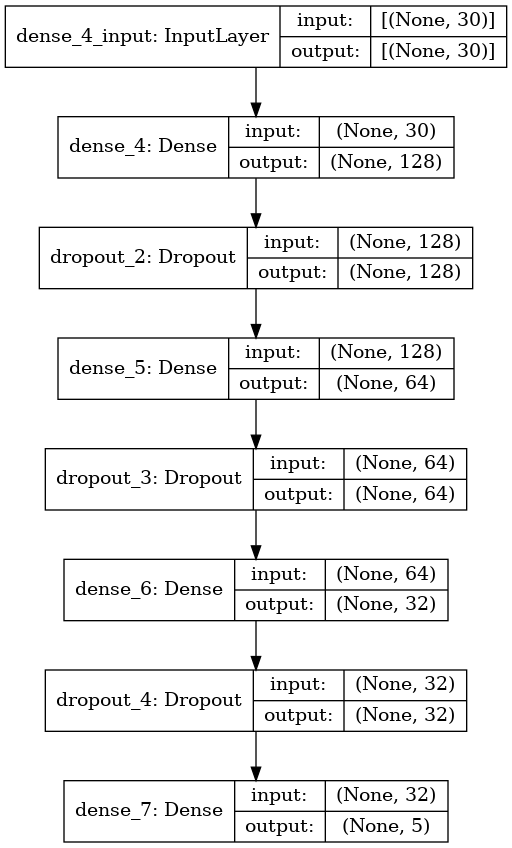

In [38]:
from tensorflow.keras.utils import plot_model


# Visualize the model
plot_model(deep_model, to_file="paper_dnn_model.png", show_shapes=True)

In [39]:
# Train the model
deep_model.fit(
    X_train, 
    Y_train.values.ravel(), 
    epochs=5, 
    batch_size=128, 
    validation_split=0.2, 
    verbose=1
)

Epoch 1/5
286/286 [==============================] - 1s 3ms/step - loss: 0.1705 - accuracy: 0.9560 - val_loss: 0.0852 - val_accuracy: 0.9673
Epoch 2/5
286/286 [==============================] - 1s 2ms/step - loss: 0.0422 - accuracy: 0.9903 - val_loss: 0.0167 - val_accuracy: 0.9976
Epoch 3/5
286/286 [==============================] - 1s 2ms/step - loss: 0.0190 - accuracy: 0.9969 - val_loss: 0.0115 - val_accuracy: 0.9984
Epoch 4/5
286/286 [==============================] - 1s 2ms/step - loss: 0.0143 - accuracy: 0.9975 - val_loss: 0.0100 - val_accuracy: 0.9980
Epoch 5/5
286/286 [==============================] - 1s 2ms/step - loss: 0.0113 - accuracy: 0.9978 - val_loss: 0.0080 - val_accuracy: 0.9979


In [40]:
shallow_preds_train = shallow_model.predict(X_train)
shallow_test = shallow_model.predict(X_test)

In [41]:
deep_preds_train = deep_model.predict(X_train)
deep_test = deep_model.predict(X_test)

In [42]:
print("SHALLOW NEURAL NETWORK")
print("Training Accuracy:", accuracy_score(Y_train, np.argmax(shallow_preds_train, axis=1)))
print("Testing Accuracy:", accuracy_score(Y_test, np.argmax(shallow_test, axis=1)))

SHALLOW NEURAL NETWORK
Training Accuracy: 0.35472152314257577
Testing Accuracy: 0.347623154583735


In [43]:
print("DEEP NEURAL NETWORK")
print("Training Accuracy:", accuracy_score(Y_train, np.argmax(deep_preds_train, axis=1)))
print("Testing Accuracy:", accuracy_score(Y_test, np.argmax(deep_test, axis=1)))

DEEP NEURAL NETWORK
Training Accuracy: 0.9977896925265346
Testing Accuracy: 0.9975648115265587


In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predicted labels
shallow_preds_labels = np.argmax(shallow_test, axis=1)
deep_preds_labels = np.argmax(deep_test, axis=1)

# Confusion Matrices
conf_matrix_shallow = confusion_matrix(Y_test, shallow_preds_labels)
conf_matrix_deep = confusion_matrix(Y_test, deep_preds_labels)

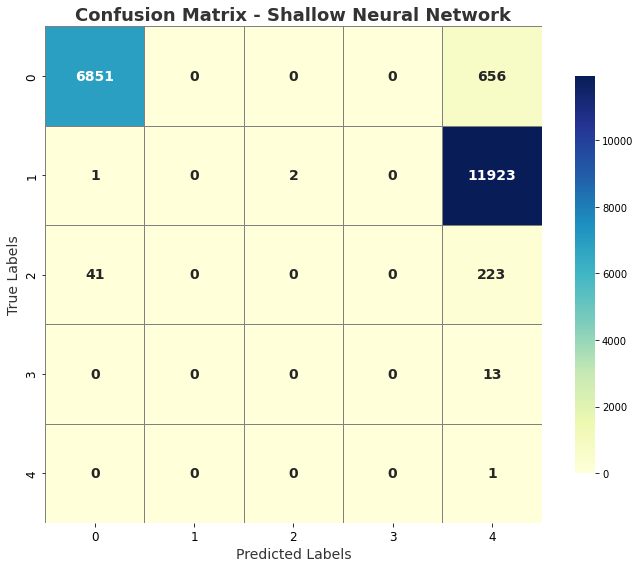

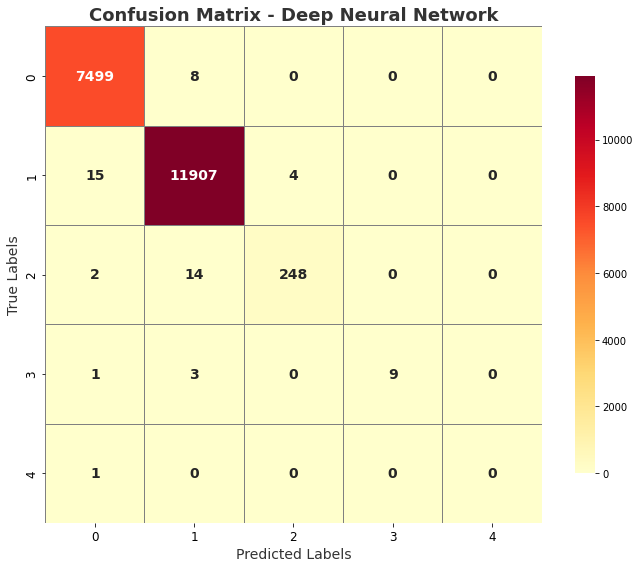

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title, cmap='coolwarm'):
    conf_mat = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_mat,
                annot=True,
                fmt='d',
                cmap=cmap,
                annot_kws={"size": 14, "weight": "bold"},
                linewidths=0.5,
                linecolor='gray',
                square=True,
                cbar_kws={"shrink": 0.8})
    plt.title(title, fontsize=18, fontweight='bold', color='#333')
    plt.xlabel('Predicted Labels', fontsize=14, color='#333')
    plt.ylabel('True Labels', fontsize=14, color='#333')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

# Use the function for Shallow and Deep NN
plot_confusion_matrix(Y_test, np.argmax(shallow_test, axis=1), "Confusion Matrix - Shallow Neural Network", cmap="YlGnBu")
plot_confusion_matrix(Y_test, np.argmax(deep_test, axis=1), "Confusion Matrix - Deep Neural Network", cmap="YlOrRd")


In [46]:
def build_shallow_model():
    model = Sequential([
        Dense(8, input_dim=30, activation='sigmoid'),
        Dropout(0.8),
        Dense(5, activation='softmax')  # Softmax for multiclass classification
    ])
    return model

def build_deep_model():
    model = Sequential([
        Dense(128, input_dim=30, activation='tanh'),
        Dropout(0.01),
        Dense(64, activation='tanh'),
        Dropout(0.01),
        Dense(32, activation='tanh'),
        Dropout(0.01),
        Dense(5, activation='softmax')
    ])
    return model


In [47]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Ensure data is in Pandas format for consistent indexing
if isinstance(X_resampled, np.ndarray):
    X = pd.DataFrame(X_resampled)
else:
    X = X_resampled.copy()

if isinstance(y_resampled, (np.ndarray, list)):
    y = pd.Series(y_resampled)
else:
    y = y_resampled.copy()

# Define train/test split sizes
train_size = 45695
test_size = 19711
total_samples = train_size + test_size

# Slice the data
X = X.iloc[:total_samples]
y = y.iloc[:total_samples]

# Perform initial train/test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    train_size=train_size,
    test_size=test_size,
    random_state=42,
    shuffle=True
)

print("Train shape:", X_train.shape, Y_train.shape)
print("Test shape:", X_test.shape, Y_test.shape)

# Define shallow and deep model builders
def build_shallow_model(input_shape=None):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, InputLayer

    model = Sequential()
    model.add(InputLayer(input_shape=input_shape))
    model.add(Dense(64, activation='tanh'))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_deep_model(input_shape=None):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, InputLayer

    model = Sequential()
    model.add(InputLayer(input_shape=input_shape))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Setup StratifiedKFold
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

shallow_scores = []
deep_scores = []

X_train_np = X_train.values
Y_train_np = Y_train.values

print("\n=== Starting K-Fold Cross-Validation ===")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, Y_train_np)):
    print(f"\n--- Fold {fold + 1} ---")

    X_train_fold, X_val_fold = X_train_np[train_idx], X_train_np[val_idx]
    Y_train_fold, Y_val_fold = Y_train_np[train_idx], Y_train_np[val_idx]

    # Build and train shallow model
    shallow_model_fold = build_shallow_model(input_shape=X_train_fold.shape[1:])
    print("Training Shallow Model...")
    shallow_model_fold.fit(X_train_fold, Y_train_fold, epochs=10, batch_size=32, verbose=1)

    # Build and train deep model
    deep_model_fold = build_deep_model(input_shape=X_train_fold.shape[1:])
    print("Training Deep Model...")
    deep_model_fold.fit(X_train_fold, Y_train_fold, epochs=10, batch_size=32, verbose=1)

    # Evaluate
    shallow_preds = np.argmax(shallow_model_fold.predict(X_val_fold), axis=1)
    deep_preds = np.argmax(deep_model_fold.predict(X_val_fold), axis=1)

    shallow_acc = accuracy_score(Y_val_fold, shallow_preds)
    deep_acc = accuracy_score(Y_val_fold, deep_preds)

    shallow_scores.append(shallow_acc)
    deep_scores.append(deep_acc)

    print(f"Shallow Accuracy: {shallow_acc:.4f}")
    print(f"Deep Accuracy:    {deep_acc:.4f}")

# Summary
print("\n=== Cross-Validation Summary ===")
print(f"Shallow NN Avg Accuracy: {np.mean(shallow_scores):.4f}")
print(f"Deep NN Avg Accuracy:    {np.mean(deep_scores):.4f}")


Train shape: (45695, 30) (45695, 1)
Test shape: (19711, 30) (19711, 1)

=== Starting K-Fold Cross-Validation ===

--- Fold 1 ---
Training Shallow Model...
Epoch 1/10


/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_split.py:680: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  UserWarning,


1143/1143 [==============================] - 2s 2ms/step - loss: 0.2088 - accuracy: 0.9516
Epoch 2/10
1143/1143 [==============================] - 2s 2ms/step - loss: 0.0910 - accuracy: 0.9661
Epoch 3/10
1143/1143 [==============================] - 2s 2ms/step - loss: 0.0603 - accuracy: 0.9814
Epoch 4/10
1143/1143 [==============================] - 2s 2ms/step - loss: 0.0405 - accuracy: 0.9955
Epoch 5/10
1143/1143 [==============================] - 2s 2ms/step - loss: 0.0294 - accuracy: 0.9969
Epoch 6/10
1143/1143 [==============================] - 2s 2ms/step - loss: 0.0225 - accuracy: 0.9972
Epoch 7/10
1143/1143 [==============================] - 2s 2ms/step - loss: 0.0186 - accuracy: 0.9975
Epoch 8/10
1143/1143 [==============================] - 2s 2ms/step - loss: 0.0161 - accuracy: 0.9978
Epoch 9/10
1143/1143 [==============================] - 2s 2ms/step - loss: 0.0140 - accuracy: 0.9979
Epoch 10/10
1143/1143 [==============================] - 2s 2ms/step - loss: 0.0123 - accurac

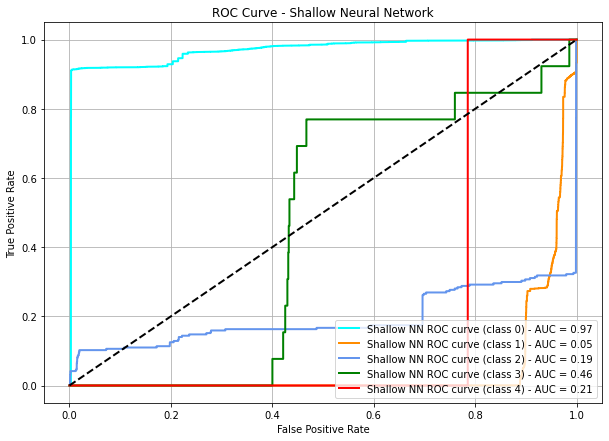

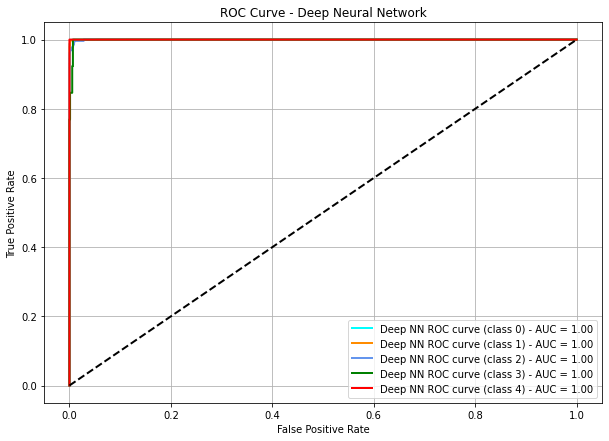

In [61]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

# Ensure predicted probabilities and one-hot labels are correct
assert shallow_probs.shape == Y_test_onehot.shape
assert deep_probs.shape == Y_test_onehot.shape

# Define class names (edit based on your actual classes)
class_names = ['class 0', 'class 1', 'class 2', 'class 3', 'class 4']
n_classes = len(class_names)
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])

# Plot ROC for Shallow Model
fpr_shallow = dict()
tpr_shallow = dict()
roc_auc_shallow = dict()

for i in range(n_classes):
    fpr_shallow[i], tpr_shallow[i], _ = roc_curve(Y_test_onehot[:, i], shallow_probs[:, i])
    roc_auc_shallow[i] = auc(fpr_shallow[i], tpr_shallow[i])

plt.figure(figsize=(10, 7))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_shallow[i], tpr_shallow[i], color=color, lw=2,
             label=f'Shallow NN ROC curve (class {i}) - AUC = {roc_auc_shallow[i]:0.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curve - Shallow Neural Network')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Repeat for Deep Model
fpr_deep = dict()
tpr_deep = dict()
roc_auc_deep = dict()

for i in range(n_classes):
    fpr_deep[i], tpr_deep[i], _ = roc_curve(Y_test_onehot[:, i], deep_probs[:, i])
    roc_auc_deep[i] = auc(fpr_deep[i], tpr_deep[i])

plt.figure(figsize=(10, 7))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_deep[i], tpr_deep[i], color=color, lw=2,
             label=f'Deep NN ROC curve (class {i}) - AUC = {roc_auc_deep[i]:0.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curve - Deep Neural Network')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [59]:
# Get predicted probabilities for both models (shallow and deep)
shallow_probs = shallow_model.predict(X_test, verbose=0)
deep_probs = deep_model.predict(X_test, verbose=0)

# Check the shapes of the predicted probabilities
print("shallow_probs shape:", shallow_probs.shape)  # Should be (19711, 5)
print("deep_probs shape:", deep_probs.shape)  # Should be (19711, 5)

# If necessary, check if the models are predicting probabilities correctly
assert shallow_probs.shape == (19711, 5), f"Expected (19711, 5), got {shallow_probs.shape}"
assert deep_probs.shape == (19711, 5), f"Expected (19711, 5), got {deep_probs.shape}"


shallow_probs shape: (19711, 5)
deep_probs shape: (19711, 5)


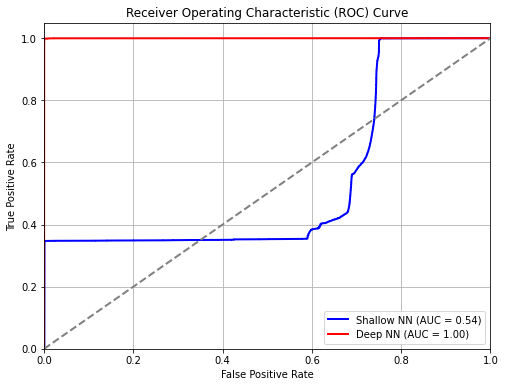

In [60]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and ROC area for each model
fpr_shallow, tpr_shallow, _ = roc_curve(Y_test_onehot.ravel(), shallow_probs.ravel())
fpr_deep, tpr_deep, _ = roc_curve(Y_test_onehot.ravel(), deep_probs.ravel())

roc_auc_shallow = auc(fpr_shallow, tpr_shallow)
roc_auc_deep = auc(fpr_deep, tpr_deep)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_shallow, tpr_shallow, color='blue', lw=2, label=f'Shallow NN (AUC = {roc_auc_shallow:.2f})')
plt.plot(fpr_deep, tpr_deep, color='red', lw=2, label=f'Deep NN (AUC = {roc_auc_deep:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Shallow Model AUC: 0.5372
Deep Model AUC: 0.9999

Shallow Model ROC Curve (FPR, TPR):
FPR: [0.         0.         0.         ... 0.99928974 0.99936584 1.        ]
TPR: [0.00000000e+00 5.07330932e-05 1.01466186e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]

Deep Model ROC Curve (FPR, TPR):
FPR: [0.         0.         0.         ... 0.99986048 0.99991122 1.        ]
TPR: [0.         0.15397494 0.16407082 ... 1.         1.         1.        ]


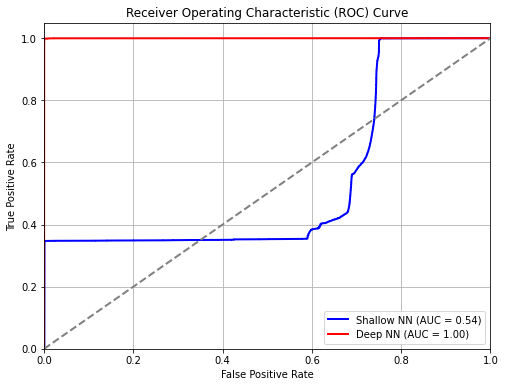

In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and ROC area for each model
fpr_shallow, tpr_shallow, _ = roc_curve(Y_test_onehot.ravel(), shallow_probs.ravel())
fpr_deep, tpr_deep, _ = roc_curve(Y_test_onehot.ravel(), deep_probs.ravel())

# Calculate AUC
roc_auc_shallow = auc(fpr_shallow, tpr_shallow)
roc_auc_deep = auc(fpr_deep, tpr_deep)

# Print the results
print(f"Shallow Model AUC: {roc_auc_shallow:.4f}")
print(f"Deep Model AUC: {roc_auc_deep:.4f}")
print("\nShallow Model ROC Curve (FPR, TPR):")
print(f"FPR: {fpr_shallow}")
print(f"TPR: {tpr_shallow}")

print("\nDeep Model ROC Curve (FPR, TPR):")
print(f"FPR: {fpr_deep}")
print(f"TPR: {tpr_deep}")

# Plotting ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_shallow, tpr_shallow, color='blue', lw=2, label=f'Shallow NN (AUC = {roc_auc_shallow:.2f})')
plt.plot(fpr_deep, tpr_deep, color='red', lw=2, label=f'Deep NN (AUC = {roc_auc_deep:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


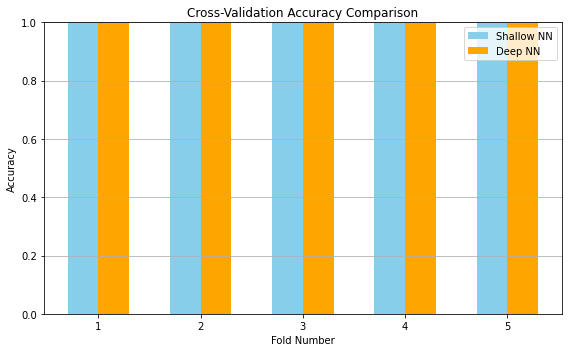

In [51]:
# Accuracy bar chart
import matplotlib.pyplot as plt
import numpy as np

folds = np.arange(1, k + 1)

plt.figure(figsize=(8, 5))
plt.bar(folds - 0.15, shallow_scores, width=0.3, label="Shallow NN", color='skyblue')
plt.bar(folds + 0.15, deep_scores, width=0.3, label="Deep NN", color='orange')

plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy Comparison")
plt.xticks(folds)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

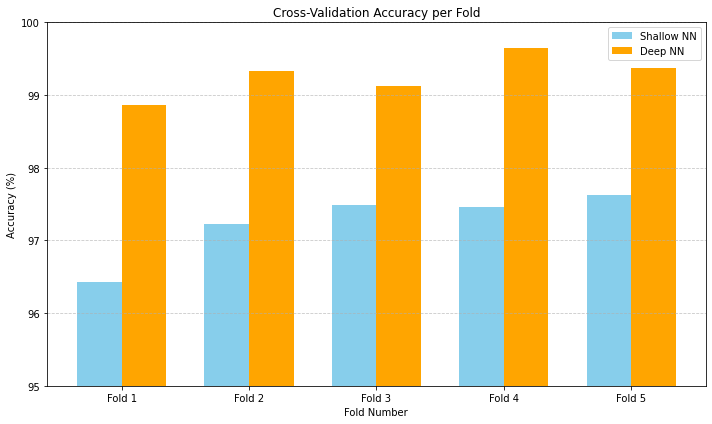

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
folds = np.array([1, 2, 3, 4, 5])
shallow_accuracies = np.array([96.43, 97.23, 97.49, 97.46, 97.63])
deep_accuracies = np.array([98.87, 99.33, 99.12, 99.65, 99.37])

# Bar width and positions
bar_width = 0.35
x = np.arange(len(folds))

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, shallow_accuracies, width=bar_width, label='Shallow NN', color='skyblue')
plt.bar(x + bar_width/2, deep_accuracies, width=bar_width, label='Deep NN', color='orange')

# Add labels and formatting
plt.xlabel("Fold Number")
plt.ylabel("Accuracy (%)")
plt.title("Cross-Validation Accuracy per Fold")
plt.xticks(x, [f"Fold {i}" for i in folds])
plt.ylim(95, 100)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Result Table

In [48]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

def generate_classification_table(model, X_test, Y_test, class_labels, dataset_type="Testing"):
    # Predict probabilities and get class predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Confusion matrix
    cm = confusion_matrix(Y_test, y_pred_classes)

    # Total samples per true class
    row_sums = cm.sum(axis=1)
    col_sums = cm.sum(axis=0)

    # Row-wise accuracy (per-class % correct)
    row_accuracy = [(cm[i][i] / row_sums[i]) * 100 if row_sums[i] > 0 else 0 for i in range(len(class_labels))]

    # Column-wise distribution (overall %)
    overall_distribution = [(col / cm.sum()) * 100 for col in col_sums]

    # Final accuracy
    final_accuracy = accuracy_score(Y_test, y_pred_classes) * 100

    # Format into DataFrame
    table = pd.DataFrame(cm, columns=class_labels, index=class_labels)
    table["% Correct"] = [f"{acc:.1f}%" for acc in row_accuracy]

    # Add "Overall %" row
    overall_row = [f"{p:.1f}%" for p in overall_distribution] + [f"{final_accuracy:.1f}%"]
    table.loc["Overall %"] = overall_row

    # Print or return table
    print(f"\n--- {dataset_type} Results ---")
    print(table.to_string())
    return table


In [49]:
class_labels = ['Buf. overflow', 'DoS', 'U2R', 'R2L', 'Probe']

# For Deep model train
deep_table = generate_classification_table(deep_model, X_train, Y_train, class_labels, dataset_type="Train Result")

# For Deep model test
deep_table = generate_classification_table(deep_model, X_test, Y_test, class_labels, dataset_type="Test Result")


--- Train Result Results ---
              Buf. overflow    DoS   U2R   R2L Probe % Correct
Buf. overflow         17687     11     0     0     0     99.9%
DoS                      17  27352     3     0     0     99.9%
U2R                       8     42   516     0     0     91.2%
R2L                       5     11     1    38     0     69.1%
Probe                     1      2     0     0     1     25.0%
Overall %             38.8%  60.0%  1.1%  0.1%  0.0%     99.8%

--- Test Result Results ---
              Buf. overflow    DoS   U2R   R2L Probe % Correct
Buf. overflow          7499      8     0     0     0     99.9%
DoS                      15  11907     4     0     0     99.8%
U2R                       2     14   248     0     0     93.9%
R2L                       1      3     0     9     0     69.2%
Probe                     1      0     0     0     0      0.0%
Overall %             38.1%  60.5%  1.3%  0.0%  0.0%     99.8%
